In [2]:
import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")

if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))



In [2]:
# create and save PSTH
from nwb_utils import NWBUtils
from behavior_utils import extract_fitted_data, find_trials,get_fitted_model_names,generate_behavior_summary
from create_psth import extract_neuron_psth_to_zarr
from behavior_utils import generate_behavior_summary_combined

session_name='ecephys_795393_2025-09-11_20-05-17_sorted_2025-10-29_15-06-02'
session_name='ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36'
session_name='ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11'
#session_name='764790_2024-12-19_16-11-34'
print(get_fitted_model_names(session_name=session_name))
save_folder="/root/capsule/scratch"
nwb_data,tag=NWBUtils.combine_nwb(session_name=session_name)

binsize=0.1
psth_da = extract_neuron_psth_to_zarr(
    nwb_data       = nwb_data,
    align_to_event = ["go_cue","reward_go_cue_start"],
    time_window    = (-6, 6),
    bin_size       = 0.1,
    save_folder    = save_folder,
    save_name      = f"{session_name}_{binsize}s",
)

generate_behavior_summary_combined(
    session_names=[session_name],
    save_result=True,
    save_folder=save_folder,
    save_name=f"behavior_summary-{session_name}.csv"
)

['QLearning_L1F0_epsi', 'WSLS', 'QLearning_L1F1_CK1_softmax', 'ForagingCompareThreshold', 'QLearning_L2F1_softmax', 'QLearning_L2F1_CKfull_softmax']
Found ephys NWB: /root/capsule/data/ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11/nwb/ecephys_795396_2025-09-20_13-11-19_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11/nwb/ecephys_795396_2025-09-20_13-11-19_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/optogenetics_nwb/795396_2025-09-20_13-11-19.nwb
Successfully read behavior NWB from: /root/capsule/data/optogenetics_nwb/795396_2025-09-20_13-11-19.nwb
Successfully appended units table to behavior NWB.
Number of units passing QC: 1298


KeyboardInterrupt: 

In [ ]:
import numpy as np

# --- Extract the laser flag array ---
laser_flags = np.asarray(nwb_data.trials['laser_on_trial'][:], dtype=int)

# --- Compute counts ---
n_all = len(laser_flags)
n_laser = np.sum(laser_flags == 1)
n_nonlaser = np.sum(laser_flags == 0)

# --- Print summary ---
print(f"Total trials: {n_all}")
print(f"Laser trials (laser_on_trial == 1): {n_laser}")
print(f"Non-laser trials (laser_on_trial == 0): {n_nonlaser}")

In [ ]:
import numpy as np

# --- NWB probe filter ---
device_names = np.asarray(nwb_data.units['device_name'][:])
# decode bytes if needed
if device_names.dtype.kind in {"S", "O"}:
    device_names = device_names.astype(str)

target_probes = ["ProbeA","ProbeC","ProbeD"]
keep_rows = np.where(np.isin(device_names, target_probes))[0]  # absolute unit IDs from NWB

# --- Match to PSTH units ---
avail = psth_da['unit_index'].values.astype(int)
keep_labels = np.intersect1d(avail, keep_rows)

# --- Make 'unit_index' the index for the 'unit' dim, then select by label ---
psth_idx = psth_da.swap_dims({'unit': 'unit_index'})  # now 'unit_index' is the dim index
psth_da_filtered = psth_idx.sel(unit_index=keep_labels)

print(f"Selected {len(keep_labels)} / {len(avail)} units")
print(dict(psth_da_filtered.dims))


In [63]:
import numpy as np
from pathlib import Path

from ephys_dimension_reduction_tdr import tdr_from_psth
from create_psth import load_zarr
from general_utils import smart_read_csv
from nwb_utils import NWBUtils  # ensure this is importable

failed_sessions = []

# Example session list (edit as needed)
sessions = ['ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36']
sessions = ['ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11']

# -------------------------
# Config
# -------------------------
binsize = '0.1'
align = "go_cue"
time_windows = [[0.3, 2], [-1, 0]]

latent_vars = [
    'QLearning_L2F1_softmax-choice','QLearning_L2F1_softmax-reward','QLearning_L2F1_softmax-RPE',
    'QLearning_L2F1_softmax-deltaQ','QLearning_L2F1_softmax-sumQ','QLearning_L2F1_softmax-chosenQ',
    'QLearning_L2F1_softmax-chosenQ-1','QLearning_L2F1_softmax-unchosenQ-1','QLearning_L2F1_softmax-unchosenQ',
    'QLearning_L2F1_softmax-deltaQ-1','QLearning_L2F1_softmax-sumQ-1'
]

#latent_vars = [
#    'QLearning_L2F1_softmax-deltaQ-1'
#]


# Keep only these probes' units
target_probes = ["ProbeA", "ProbeC", "ProbeD"]  # change as needed

for session in sessions:
    try:
        # -------------------------
        # Load PSTH dataset & behavior summary
        # -------------------------
        psth_da = load_zarr(f"/root/capsule/scratch/{session}_{binsize}s.zarr")
        df = smart_read_csv(f"/root/capsule/scratch/behavior_summary-{session}.csv")

        if 'response_trials' not in df.columns:
            raise KeyError("Column 'response_trials' missing in behavior summary CSV.")

        # response_ids are ABSOLUTE trial indices, and the order here defines
        # the order of all response-only latent vectors in the CSV.
        response_ids = np.asarray(df['response_trials'][0], dtype=int)
        if response_ids.ndim != 1:
            raise ValueError("response_trials must be a 1D sequence of absolute trial indices.")

        # -------------------------
        # Open NWB to get laser flags and filter to NON-LASER
        # -------------------------
        nwb_data, tag = NWBUtils.combine_nwb(session_name=session)
        if nwb_data is None:
            raise RuntimeError(f"Could not open NWB for session: {session}")

        # laser_on_trial is in absolute trial space (same space as response_ids)
        laser_flags = np.asarray(nwb_data.trials['laser_on_trial'][:], dtype=int)
        if laser_flags.ndim != 1:
            raise ValueError("nwb_data.trials['laser_on_trial'] must be a 1D array.")

        # Absolute trial indices where laser was OFF
        nonlaser_ids = np.where(laser_flags == 0)[0]

        # -------------------------
        # Map ABSOLUTE non-laser to RESPONSE-ONLY order
        # -------------------------
        # Build a boolean mask in response-only index space:
        # keep those response trials whose absolute ID is in nonlaser_ids.
        resp_keep_mask = np.isin(response_ids, nonlaser_ids)

        # include_trials are ABSOLUTE trial ids, but ordered exactly as the filtered response-only order
        include_trials = response_ids[resp_keep_mask]

        if include_trials.size == 0:
            raise RuntimeError(f"No trials left after response ∩ non-laser filter for {session}")

        # -------------------------
        # Unit filter: keep only units on target probes
        # -------------------------
        device_names = np.asarray(nwb_data.units['device_name'][:])
        # Normalize to str array if needed
        if device_names.dtype.kind in {"S", "O"}:
            device_names = device_names.astype(str)

        # Absolute NWB unit IDs to keep (by probe name)
        keep_rows = np.where(np.isin(device_names, target_probes))[0]

        # psth_da typically stores absolute NWB unit IDs in the 'unit_index' coordinate
        if 'unit_index' not in psth_da.coords:
            raise KeyError("PSTH zarr is expected to have a 'unit_index' coordinate of absolute unit IDs.")

        avail_labels = psth_da['unit_index'].values.astype(int)

        # Positions along the 'unit' dimension whose unit_index labels are in keep_rows
        pos = np.nonzero(np.isin(avail_labels, keep_rows))[0]
        if pos.size == 0:
            raise RuntimeError(f"No units on probes {target_probes} for session {session}")

        # Select units to keep
        # Note: We index the 'unit' dimension positions, leaving 'unit_index' labels intact.
        psth_da_filtered = psth_da.isel(unit=pos)

        print(f"[INFO] {session}: units kept {len(pos)}/{psth_da.sizes['unit']}, "
              f"trials kept {include_trials.size}/{len(laser_flags)} (response ∩ non-laser)")

        # -------------------------
        # Run TDR for all windows × latent vars
        # -------------------------
        for time_window in time_windows:
            tw0, tw1 = time_window[0], time_window[1]

            for latent_var in latent_vars:
                if latent_var not in df.columns:
                    print(f"[WARN] '{latent_var}' not in behavior CSV. Skipping.")
                    continue

                # Latent vectors here are already RESPONSE-ONLY and aligned to response_ids order.
                latent_response_only = np.asarray(df[latent_var][0], dtype=float)

                # Sanity check: response-only latent length must match response_ids length.
                if latent_response_only.shape[0] != response_ids.shape[0]:
                    raise ValueError(
                        f"Length mismatch for {latent_var}: "
                        f"latent={latent_response_only.shape[0]} vs response_ids={response_ids.shape[0]}"
                    )

                # Subset latent to response ∩ non-laser using the response-only mask
                latent_filtered = latent_response_only[resp_keep_mask]

                # Final alignment sanity check
                if latent_filtered.size != include_trials.size:
                    raise RuntimeError(
                        f"After filtering, latent size ({latent_filtered.size}) "
                        f"!= include_trials size ({include_trials.size})."
                    )

                save_path = (
                    f"/root/capsule/scratch/"
                    f"tdr_{session}_{latent_var}_timewindow_{tw0}_{tw1}.zarr"
                )

                out = tdr_from_psth(
                    psth_da_filtered,          # unit-filtered PSTH; dim name is 'unit'
                    latent=latent_filtered,    # response ∩ non-laser, in response-only order
                    align=align,
                    time_window=[tw0, tw1],
                    include_trials=include_trials,   # ABSOLUTE trial ids, order matches latent_filtered
                    require_all_ids=True,
                    save_path=save_path,
                    save_format="zarr",
                )

                if isinstance(out, dict):
                    print(f"[OK] {session} | {latent_var} | tw={[tw0, tw1]} → keys: {list(out)[:5]}")
                else:
                    print(f"[OK] {session} | {latent_var} | tw={[tw0, tw1]} → saved to {save_path}")

    except Exception as e:
        print(f"❌ Error in session {session}: {e}")
        failed_sessions.append(session)

print("\nAll sessions done.")
if failed_sessions:
    print("Failed sessions:")
    for s in failed_sessions:
        print(f" - {s}")
else:
    print("No errors 🎉")


Found ephys NWB: /root/capsule/data/ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11/nwb/ecephys_795396_2025-09-20_13-11-19_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11/nwb/ecephys_795396_2025-09-20_13-11-19_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/optogenetics_nwb/795396_2025-09-20_13-11-19.nwb
Successfully read behavior NWB from: /root/capsule/data/optogenetics_nwb/795396_2025-09-20_13-11-19.nwb
Successfully appended units table to behavior NWB.
[INFO] ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11: units kept 1284/1298, trials kept 559/648 (response ∩ non-laser)
[OK] ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11 | QLearning_L2F1_softmax-choice | tw=[0.3, 2] → keys: ['cv_corr', 'cv_r2', 'y_cv', 'z_cv', 'final']
[OK] ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11 | QLearning_L2F1_softmax-reward | tw=[0.3, 2

In [ ]:
ds['trial_id'].values

Found 1 matching files
Loaded ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36: all trials from tdr_ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36_QLearning_L2F1_softmax-sumQ-1_timewindow_-1_0.zarr
Combined Y shape: (505, 120)
Combined y_fit length: (505,)
Combined latent length: (505,)


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_tdr.py:1158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.82, 1])


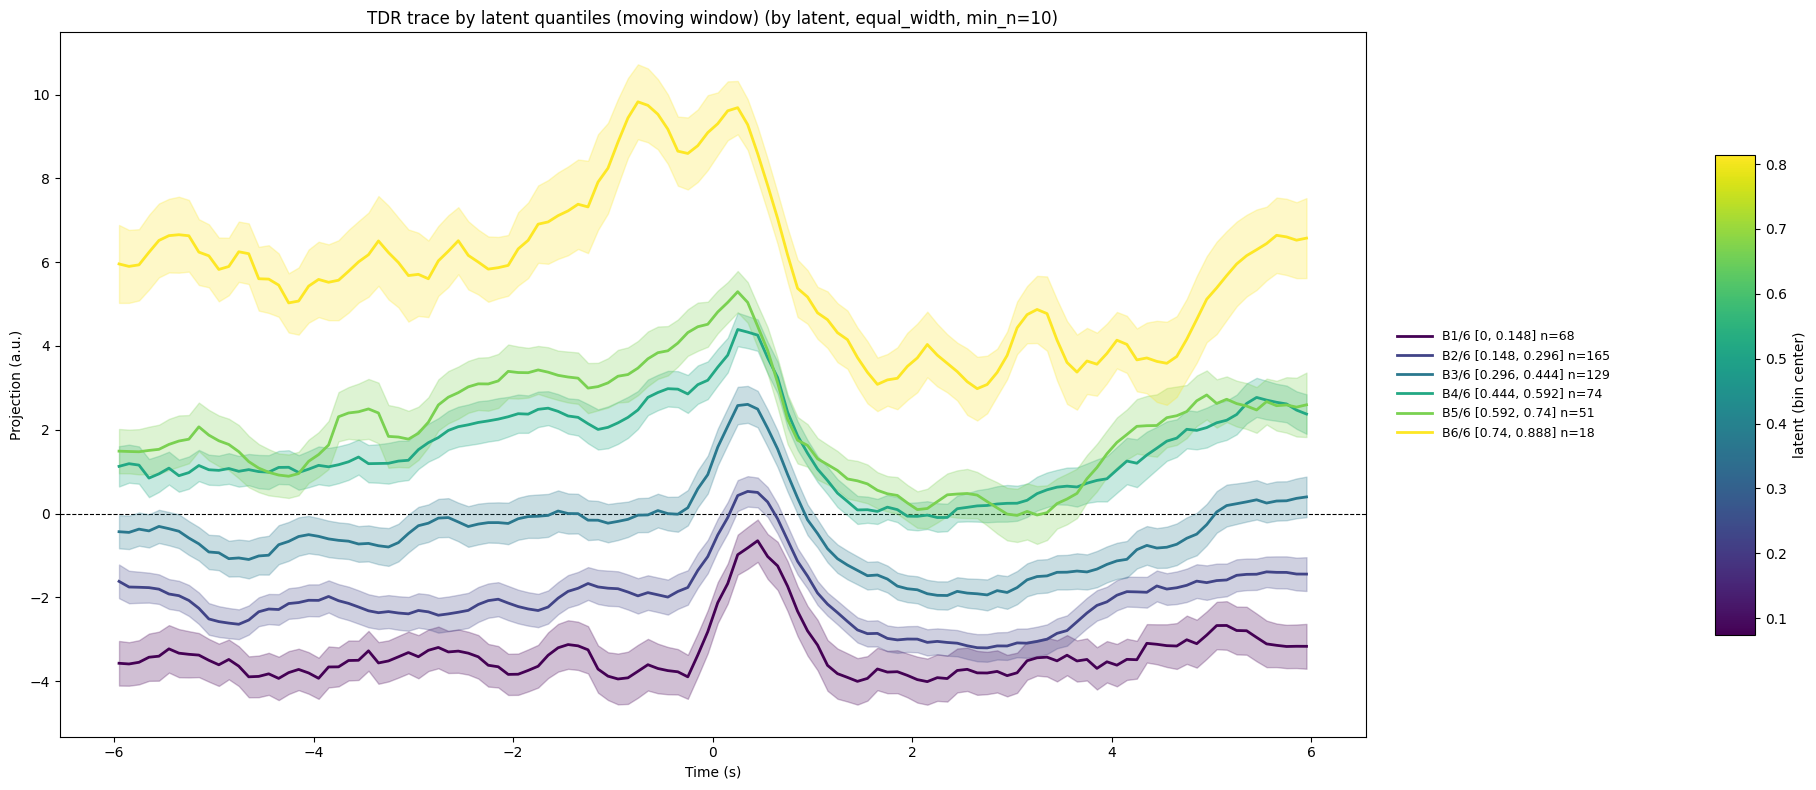

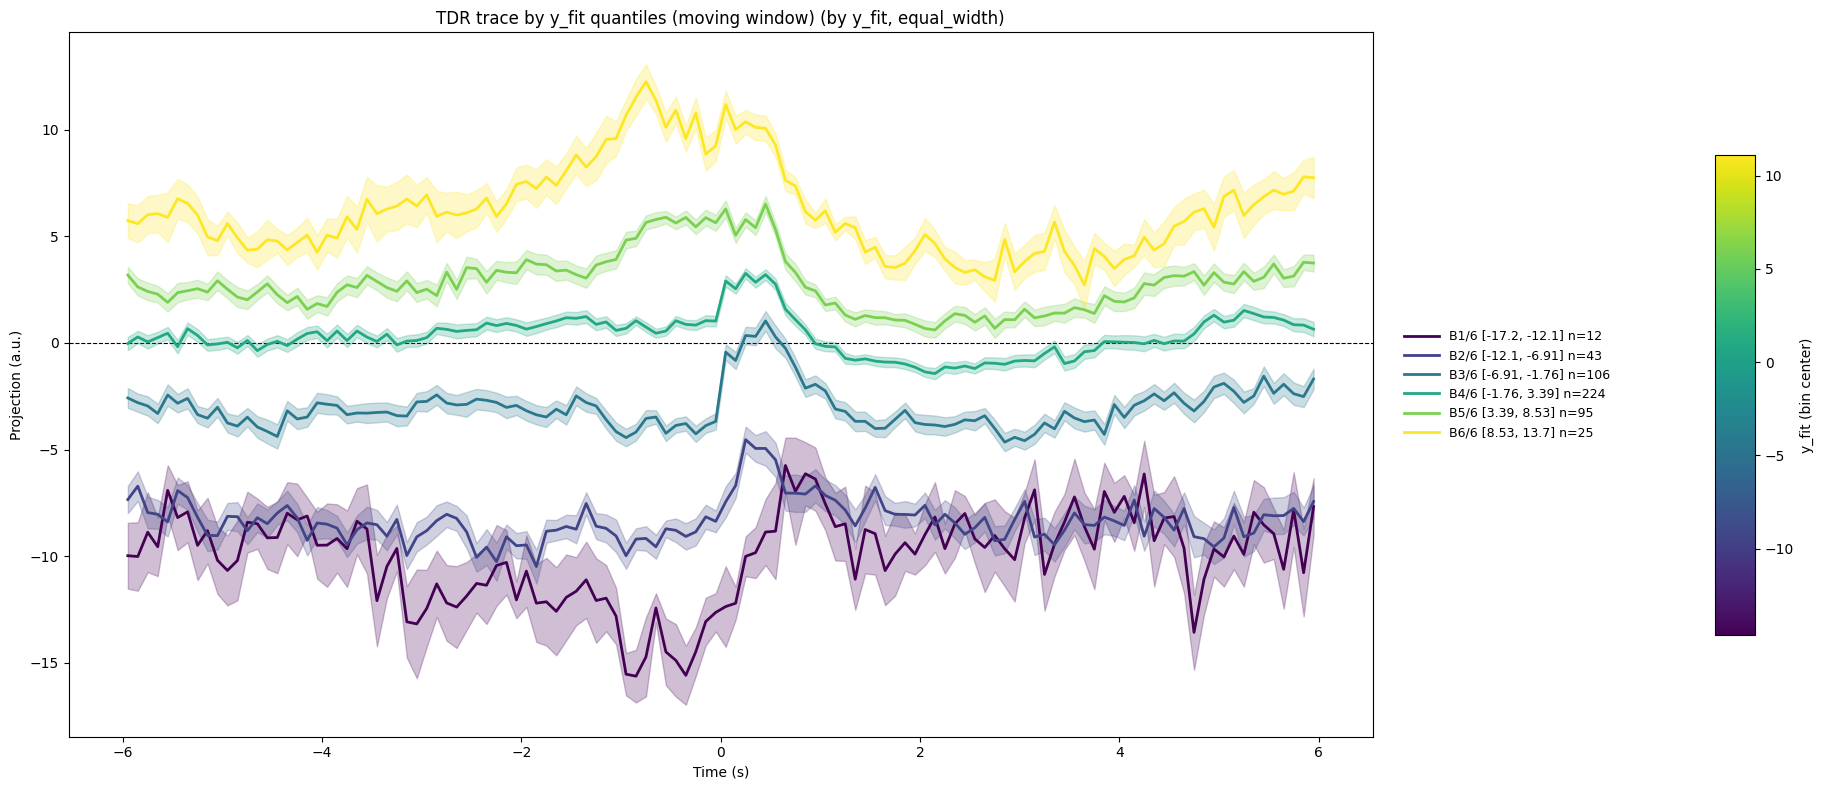

In [3]:
import os
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
from general_utils import smart_read_csv  # assuming this is defined elsewhere
from general_utils import find_ephys_sessions
from ephys_dimension_reduction_tdr import plot_tdr_trace_by_quantile
# -------------------------
# Config: restrict sessions
# -------------------------
sessions=['ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36']
#sessions=['ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11']
to_mask = False
base_dir = Path("/root/capsule/scratch/tdr_results/")
base_dir_behavior = Path("/root/capsule/scratch/behavior_summary/")
#end_with = "ForagingCompareThreshold-value-1_timewindow_-1_0.zarr"
# Examples you might swap in:
# end_with = "QLearning_L2F1_softmax-reward_timewindow_0.3_2.zarr"
# end_with = "ForagingCompareThreshold-RPE_timewindow_0.3_2.zarr"
# end_with = "QLearning_L2F1_softmax-RPE_timewindow_0.3_2.zarr"
end_with = "QLearning_L2F1_softmax-sumQ-1_timewindow_-1_0.zarr"
#end_with = "QLearning_L2F1_softmax-deltaQ-1_timewindow_-1_0.zarr"
# -----------------------------------------
# Build explicit zarr paths from session IDs
# -----------------------------------------
zarr_paths = []
for sess in sessions:
    # Files are expected to be named like:
    # f"tdr_{session}_{<latent>}_timewindow_<start>_<end>.zarr"
    # Since we don't know the latent part here, we match by suffix (end_with)
    # and prefix "tdr_{session}_".
    prefix = f"tdr_{sess}_"
    # Find matching files in base_dir
    matches = [str(base_dir / f) for f in os.listdir(base_dir)
               if f.startswith(prefix) and f.endswith(end_with)]
    if not matches:
        print(f"⚠️ No Zarr found for session={sess} with suffix '{end_with}'.")
    else:
        zarr_paths.extend(matches)

print(f"Found {len(zarr_paths)} matching files")

# ----------------
# Containers
# ----------------
Y_list, yfit_list, latent_list, latent_list_z = [], [], [], []
t_ref = None
loaded_any = False

# -----------------------------
# Process each Zarr (per file)
# -----------------------------
for path in zarr_paths:
    try:
        # Derive session name back from filename (prefix we used above)
        # Format assumed: tdr_{session}_{latent}_timewindow_... .zarr
        fname = os.path.basename(path)
        # Recover the session string between "tdr_" and the next "_"
        # But session itself contains underscores, so split by the known suffix:
        # We already know the session; for logging, pull it from the filename safely:
        for sess in sessions:
            if fname.startswith(f"tdr_{sess}_"):
                session = sess
                break
        else:
            session = "<unknown-session>"

        # Load behavior summary (needed for masking switch trials)
        csv_path = base_dir_behavior / f"behavior_summary-{session}.csv"
        if not csv_path.exists():
            print(f"⚠️ Missing behavior CSV for {session}: {csv_path}")
            continue

        df = smart_read_csv(str(csv_path))

        # Provide a default if the column isn't present
        if "switch_trial_noreward_trials" in df.columns:
            switch_trial_trials_ID = np.asarray(df["switch_trial_noreward_trials"][0], dtype=int)
        else:
            switch_trial_trials_ID = np.array([], dtype=int)

        # Open TDR result
        ds = xr.open_zarr(path, consolidated=False)

        # Sanity checks for required variables
        for v in ["projection_trace", "projection", "latent", "latent_z", "trial_id", "time"]:
            if v not in ds:
                raise KeyError(f"Variable '{v}' not found in {path}")

        trial_ids = ds["trial_id"].values

        # Keep a reference time axis (assumed identical across files for same settings)
        t_cur = ds["time"].values
        if t_ref is None:
            t_ref = t_cur
        else:
            # Soft check: same length/timebase
            if len(t_ref) != len(t_cur) or not np.allclose(t_ref, t_cur, equal_nan=True):
                print(f"⚠️ Time axis differs in {path}; using the first loaded time as reference.")

        if to_mask and switch_trial_trials_ID.size > 0:
            mask = np.isin(trial_ids, switch_trial_trials_ID)
            Y_list.append(ds["projection_trace"].values[mask])  # (n_masked_trials, n_time)
            yfit_list.append(ds["projection"].values[mask])     # (n_masked_trials,)
            latent_list.append(ds["latent"].values[mask])       # (n_masked_trials,)
            latent_list_z.append(ds["latent_z"].values[mask])   # (n_masked_trials,)
            print(f"Loaded {session}: {mask.sum()} switch trials extracted from {os.path.basename(path)}")
        else:
            # No masking → use all trials
            Y_list.append(ds["projection_trace"].values)   # (n_trials, n_time)
            yfit_list.append(ds["projection"].values)      # (n_trials,)
            latent_list.append(ds["latent"].values)        # (n_trials,)
            latent_list_z.append(ds["latent_z"].values)    # (n_trials,)
            print(f"Loaded {session}: all trials from {os.path.basename(path)}")

        loaded_any = True

    except Exception as e:
        print(f"❌ Error reading {path}: {e}")

if not loaded_any:
    raise RuntimeError("No data loaded. Check 'sessions', 'end_with', and file availability.")

# ---------------------------------
# Concatenate across all zarr files
# ---------------------------------
Y = np.concatenate(Y_list, axis=0)              # (N_total_trials, n_time)
y_fit = np.concatenate(yfit_list, axis=0)       # (N_total_trials,)
latent_inc = np.concatenate(latent_list, axis=0)
latent_inc_z = np.concatenate(latent_list_z, axis=0)
t = t_ref

print(f"Combined Y shape: {Y.shape}")
print(f"Combined y_fit length: {y_fit.shape}")
print(f"Combined latent length: {latent_inc.shape}")

# -----------------
# Plotting examples
# -----------------
# 1) Quantiles by latent (moving window smoothing example; set window to your binsize)
plot_tdr_trace_by_quantile(
    Y, t, latent=latent_inc, n_quantiles=6,
    group_by="latent", ci="sem", show_trials=False,
    min_traces_per_bin=10,
    smooth={"method": "moving", "window": 5, "unit": "samples"},  # ~0.5 s if binsize=0.1 s
    title="TDR trace by latent quantiles (moving window)"
)

# 2) Quantiles by y_fit (projection), with optional smoothing
plot_tdr_trace_by_quantile(
    Y, t, latent=latent_inc_z, n_quantiles=6,
    y_fit=y_fit, group_by="y_fit", ci="sem",
    smooth={"method": "moving", "window": 1, "unit": "samples"},  # no smoothing
    title="TDR trace by y_fit quantiles (moving window)"
)


In [4]:
import numpy as np
import pandas as pd

# Extract trial-level data
laser_on = np.asarray(nwb_data.trials['laser_on_trial'][:])
laser_start = np.asarray(nwb_data.trials['laser_start'][:])
laser_start_offset = np.asarray(nwb_data.trials['laser_start_offset'][:])
laser_end = np.asarray(nwb_data.trials['laser_end'][:])
laser_end_offset = np.asarray(nwb_data.trials['laser_end_offset'][:])
laser_duration = np.asarray(nwb_data.trials['laser_duration'][:])
trial_ids = np.arange(len(laser_on))

# Build DataFrame (include all trials, but we’ll filter laser_on == 1)
df = pd.DataFrame({
    'trial_id': trial_ids,
    'laser_on_trial': laser_on,
    'laser_start': laser_start,
    'laser_start_offset': laser_start_offset,
    'laser_end': laser_end,
    'laser_end_offset': laser_end_offset,
    'laser_duration': laser_duration,
})

# Keep only trials with laser_on_trial == 1
df_laser = df[df['laser_on_trial'] == 1].copy()

# Group by all laser parameters and aggregate trial IDs
summary = (
    df_laser
    .groupby(['laser_start', 'laser_start_offset', 'laser_end', 'laser_end_offset', 'laser_duration'])
    .agg(
        n_trials=('trial_id', 'size'),
        trial_ids=('trial_id', lambda x: list(x))
    )
    .reset_index()
    .sort_values('n_trials', ascending=False)
)

print(summary)


NameError: name 'nwb_data' is not defined

In [5]:
import numpy as np
import xarray as xr
from pathlib import Path

from create_psth import load_zarr
from general_utils import smart_read_csv
from nwb_utils import NWBUtils

from importlib import reload
import ephys_dimension_reduction_tdr

reload(ephys_dimension_reduction_tdr)   # re-import updated code


# If your plot helper lives in the same module as TDR (per your paste), import it:
from ephys_dimension_reduction_tdr import plot_tdr_trace_by_quantile

# ============================================================
# Config
# ============================================================
session = 'ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36'
#session = 'ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11'

binsize = '0.2'
align = "go_cue"                     # {"go_cue","reward_go_cue_start"}
# Choose the SAME time window & latent you used to train/save the TDR:
time_window = [-1, 0]
latent_var = 'QLearning_L2F1_softmax-sumQ-1'

# Keep only these probes' units
target_probes = ["ProbeA", "ProbeC", "ProbeD"]

# Plotting params
plot_kwargs = dict(
    n_quantiles=6,
    group_by="latent",
    ci="sem",
    show_trials=False,
    min_traces_per_bin=2,
    smooth={"method": "moving", "window": 5, "unit": "samples"},
    title=f"TDR trace by {latent_var} quantiles (window {time_window[0]},{time_window[1]})"
)

# ============================================================
# Helpers
# ============================================================

def _find_trial_dim_and_coord(obj: xr.DataArray) -> tuple[str, str]:
    """
    Return (trial_dim_name, trial_coord_name).
    Prefers dims containing 'trial'; coord must be int-labeled absolute trial IDs.
    """
    # Common names first
    for td in ["trial_go_cue", "trial_reward_go_cue_start", "trial", "trials"]:
        if td in obj.dims:
            if td in obj.coords:
                if np.issubdtype(obj[td].dtype, np.integer):
                    return td, td
            # else find an integer coord on that dim
            for c in obj.coords:
                if td in obj[c].dims and np.issubdtype(obj[c].dtype, np.integer):
                    return td, c
    # Fallback scan
    for d in obj.dims:
        if "trial" in d:
            for c in obj.coords:
                if d in obj[c].dims and np.issubdtype(obj[c].dtype, np.integer):
                    return d, c
    raise RuntimeError("Could not infer trial dimension/coordinate (need an int-labeled trial coord).")

def _choose_psth_array(psth_ds: xr.Dataset) -> xr.DataArray:
    """
    Return a DataArray view of the PSTH with dims including ('unit', trial_dim, 'time').
    If a Dataset, pick a variable that has both 'unit' and 'time' dims (e.g., psth_go_cue).
    """
    if isinstance(psth_ds, xr.DataArray):
        return psth_ds
    # Prefer explicit names
    for name in ["psth_go_cue", "psth_reward_go_cue_start"]:
        if name in psth_ds.data_vars and 'unit' in psth_ds[name].dims and 'time' in psth_ds[name].dims:
            return psth_ds[name]
    # Otherwise pick the first that matches ('unit','time')
    for name, var in psth_ds.data_vars.items():
        if 'unit' in var.dims and 'time' in var.dims:
            return psth_ds[name]
    raise RuntimeError("No DataArray with dims including ('unit','time') found in PSTH dataset.")

def _load_tdr_axis_from_ds(tdr_ds: xr.Dataset) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns (w, unit_labels) from your saved zarr (produced by _package_tdr_to_xr in your TDR code).
    - w: (N_units,)
    - unit_labels: (N_units,) absolute NWB unit IDs (from coord 'unit_id')
    """
    if "axis_w" not in tdr_ds:
        # fallback scan if you saved differently
        for k in ["projection_axis", "axis_weights", "weights", "w", "u", "tdr_axis"]:
            if k in tdr_ds:
                arr = np.asarray(tdr_ds[k].values).astype(float).ravel()
                if "unit_id" in tdr_ds.coords:
                    return arr, np.asarray(tdr_ds["unit_id"].values).astype(int)
                if "unit_index" in tdr_ds.coords:
                    return arr, np.asarray(tdr_ds["unit_index"].values).astype(int)
                return arr, np.arange(arr.shape[0], dtype=int)
        raise KeyError("No axis found in TDR dataset (expected 'axis_w').")
    w = np.asarray(tdr_ds["axis_w"].values).astype(float).ravel()
    if "unit_id" not in tdr_ds.coords:
        raise KeyError("Saved TDR zarr is missing the 'unit_id' coordinate.")
    unit_labels = np.asarray(tdr_ds["unit_id"].values).astype(int)
    if unit_labels.shape[0] != w.shape[0]:
        raise ValueError("axis_w length does not match unit_id length in TDR dataset.")
    return w, unit_labels

# ============================================================
# 1) Load PSTH & behavior CSV
# ============================================================
psth = load_zarr(f"/root/capsule/scratch/psth_results/{session}_{binsize}s.zarr")
df = smart_read_csv(f"/root/capsule/scratch/behavior_summary/behavior_summary-{session}.csv")
if 'response_trials' not in df.columns:
    raise KeyError("Column 'response_trials' missing in behavior summary CSV.")
response_ids = np.asarray(df['response_trials'][0], dtype=int)

psth_arr = _choose_psth_array(psth)   # DataArray with dims ('unit', trial_dim, 'time')
if 'unit_index' not in psth_arr.coords:
    raise KeyError("PSTH zarr must have a 'unit_index' coordinate with absolute unit IDs.")
trial_dim, trial_coord = _find_trial_dim_and_coord(psth_arr)

# ============================================================
# 2) Open NWB & build trial mask: response ∩ non-laser
# ============================================================
nwb_data, tag = NWBUtils.combine_nwb(session_name=session)

#laser_flags = np.asarray(nwb_data.trials['laser_on_trial'][:], dtype=int)
#nonlaser_ids = np.where(laser_flags == 0)[0]

#resp_keep_mask = np.isin(response_ids, nonlaser_ids)
#include_trials = response_ids[resp_keep_mask]
#if include_trials.size == 0:
#    raise RuntimeError("No trials left after response ∩ non-laser.")

# --- select the trial IDs for the desired laser condition ---
include_trials = np.array(summary['trial_ids'][0], dtype=int)-1 # Go cue offset 0.3s stimulation
include_trials = np.array(summary['trial_ids'][1], dtype=int)-1 # ITI stimulation 
#include_trials = onlaser_ids = np.where(laser_flags == 0)[0] # control trials

# --- keep only those that are also response trials ---
include_trials = np.intersect1d(include_trials, response_ids)

resp_keep_mask = np.isin(response_ids, include_trials)
# ============================================================
# 3) Filter units by probe
# ============================================================
device_names = np.asarray(nwb_data.units['device_name'][:])
if device_names.dtype.kind in {"S", "O"}:
    device_names = device_names.astype(str)
keep_rows = np.where(np.isin(device_names, target_probes))[0]

avail_labels = psth_arr['unit_index'].values.astype(int)
unit_pos = np.nonzero(np.isin(avail_labels, keep_rows))[0]
if unit_pos.size == 0:
    raise RuntimeError(f"No units on probes {target_probes} for session {session}")

psth_arr_filt = psth_arr.isel(unit=unit_pos)   # keep 'unit' dim; 'unit_index' coord stays aligned

# ============================================================
# 4) Load TDR zarr for (latent_var, time_window) and get axis_w
# ============================================================
tw0, tw1 = time_window
tdr_path = f"/root/capsule/scratch/tdr_results/tdr_{session}_{latent_var}_timewindow_{tw0}_{tw1}.zarr"
tdr_ds = xr.open_zarr(tdr_path, consolidated=False)

tdr_w, tdr_units = _load_tdr_axis_from_ds(tdr_ds)   # weights and their unit_id labels

# Align TDR weights to the filtered PSTH unit order
p_units = psth_arr_filt['unit_index'].values.astype(int)
index_in_tdr = {u: i for i, u in enumerate(tdr_units)}
order = np.array([index_in_tdr.get(u, -1) for u in p_units])
valid = order >= 0
if not np.any(valid):
    raise RuntimeError("No overlapping units between PSTH (after probe filter) and TDR axis.")

psth_arr_filt = psth_arr_filt.isel(unit=np.where(valid)[0])
p_units = p_units[valid]
w_aligned = tdr_w[order[valid]]

# ============================================================
# 5) Slice PSTH to requested absolute trials (keep requested order)
# ============================================================
trial_labels = psth_arr_filt[trial_coord].values
pos_by_id = {tid: i for i, tid in enumerate(trial_labels)}
missing = [tid for tid in include_trials if tid not in pos_by_id]
if len(missing) > 0:
    raise RuntimeError(f"{len(missing)} requested trials not found in PSTH trial coord: e.g., {missing[:10]}")
trial_pos = np.array([pos_by_id[tid] for tid in include_trials])

psth_sel = psth_arr_filt.isel({trial_dim: trial_pos})  # dims: (unit, time, trial_dim) or similar

# Reorder to (unit, time, trials)
dims = list(psth_sel.dims)
u_ax = dims.index('unit')
t_ax = dims.index('time')
tr_ax = [i for i, d in enumerate(dims) if d == trial_dim][0]
X = np.moveaxis(psth_sel.values, [u_ax, t_ax, tr_ax], [0, 1, 2])  # (unit, time, trials)

# ============================================================
# 6) Project: Y = wᵀ · X  → (trials, time)
# ============================================================
Y = np.einsum('u,utk->tk', w_aligned, X).T  # (trials, time)
t = psth_sel['time'].values

# Latent for the selected trials (response-only latent, filtered to non-laser in same order)
latent_response_only = np.asarray(df[latent_var][0], dtype=float)
if latent_response_only.shape[0] != response_ids.shape[0]:
    raise ValueError(f"Latent length mismatch for {latent_var}: {latent_response_only.shape[0]} vs response_ids {response_ids.shape[0]}")
latent_filtered = latent_response_only[resp_keep_mask]  # same order as include_trials

# Final checks
assert Y.shape[0] == include_trials.size
assert latent_filtered.shape[0] == include_trials.size

print(f"[INFO] Projection built: Y {Y.shape}, t {t.shape}, latent {latent_filtered.shape}")

# ============================================================
# 7) Visualization
# ============================================================
plot_tdr_trace_by_quantile(
    Y, t, latent=latent_filtered,
    **plot_kwargs
)


Found ephys NWB: /root/capsule/data/ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36/nwb/ecephys_795393_2025-09-15_13-05-25_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36/nwb/ecephys_795393_2025-09-15_13-05-25_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/optogenetics_nwb/795393_2025-09-15_13-05-25.nwb
Successfully read behavior NWB from: /root/capsule/data/optogenetics_nwb/795393_2025-09-15_13-05-25.nwb
Successfully appended units table to behavior NWB.


NameError: name 'summary' is not defined

In [14]:
from __future__ import annotations

from pathlib import Path
from typing import Any

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import fdrcorrection


def plot_psth_condition_scatter(
    psth_ds: xr.Dataset,
    nwb_data: Any,
    trials_a: np.ndarray,
    trials_b: np.ndarray,
    target_probes: list[str],
    *,
    align: str = "go_cue",                 # {"go_cue","reward_go_cue_start"}
    time_window: tuple[float, float] = (0.0, 0.5),
    alpha: float = 0.05,                   # per-test alpha
    use_fdr: bool = True,                  # Benjamini–Hochberg across units
    equal_var: bool = False,               # Welch's t-test by default
    marker_size: float = 30.0,
    title: str | None = None,
    # -----------------------------
    # NEW: saving + display controls
    # -----------------------------
    save_path: str | Path | None = None,
    save_format: str | list[str] = ["eps","png"],
    dpi: int = 600,
    overwrite: bool = True,
    show: bool = True,
):
    """
    Scatter plot of mean PSTH activity (cond A vs cond B) per neuron, with significance.

    Parameters
    ----------
    psth_ds : xr.Dataset
        Dataset containing PSTH data variables and coordinates, including:
        - 'unit_index' coordinate (absolute NWB unit IDs)
        - 'time' coordinate
        - trial index coordinate matching `align` (e.g. 'trial_index_go_cue')
    nwb_data : Any
        NWB object providing units table with 'device_name' for probe filtering.
        Must support: nwb_data.units['device_name'][:]
    trials_a : np.ndarray
        Absolute trial IDs defining condition A.
    trials_b : np.ndarray
        Absolute trial IDs defining condition B.
    target_probes : list[str]
        Probe / device names to include (matched against nwb_data.units['device_name']).

    align : str, default "go_cue"
        Which PSTH alignment to use. One of {"go_cue", "reward_go_cue_start"}.
    time_window : (float, float), default (0.0, 0.5)
        Time window for averaging firing rate (seconds).
    alpha : float, default 0.05
        Significance threshold (per test if use_fdr=False; FDR target if use_fdr=True).
    use_fdr : bool, default True
        If True, apply BH-FDR across units (valid p-values only).
    equal_var : bool, default False
        Passed to scipy.stats.ttest_ind (False = Welch's t-test).
    marker_size : float, default 30.0
        Scatter marker size.
    title : str | None
        Plot title prefix.

    save_path : str | Path | None
        If provided, save figure. If a directory path (no suffix), saves into that directory
        using a default base name. If a file-like path with suffix (e.g. ".../name.png"),
        the stem is used and suffix is replaced per save_format.
    save_format : str | list[str], default "png"
        File format(s) to save: "png", "eps", "pdf", or a list like ["png","eps"].
    dpi : int, default 300
        DPI used for saving raster formats (png). Safe to set for eps/pdf too.
    overwrite : bool, default True
        If False, skip saving any file that already exists.
    show : bool, default True
        If True, display the figure. If False, close after saving.

    Returns
    -------
    dict(
        mean_a, mean_b, pvals, qvals, sig_mask, unit_ids, fig, ax,
        n_valid, n_sig, n_sig_inc, n_sig_dec,
        frac_inc_all, frac_dec_all, frac_inc_sig, frac_dec_sig,
        inc_mask, dec_mask
    )
    """

    # -----------------------------
    # Normalize save_format
    # -----------------------------
    if isinstance(save_format, str):
        save_formats = [save_format.lower()]
    else:
        save_formats = [str(fmt).lower() for fmt in save_format]

    valid_formats = {"png", "eps", "pdf"}
    for fmt in save_formats:
        if fmt not in valid_formats:
            raise ValueError(f"Unsupported save_format '{fmt}'. Must be one of {valid_formats}.")

    # ----- choose data variable / trial dims from align -----
    if align == "go_cue":
        var = "psth_go_cue"
        trial_dim = "trial_go_cue"
        trial_coord = "trial_index_go_cue"
    elif align == "reward_go_cue_start":
        var = "psth_reward_go_cue_start"
        trial_dim = "trial_reward_go_cue_start"
        trial_coord = "trial_index_reward_go_cue_start"
    else:
        raise ValueError(f"Unknown align='{align}'")

    if var not in psth_ds.data_vars:
        raise KeyError(f"{var} not found in psth dataset data_vars.")

    da = psth_ds[var]  # (unit, trial, time)
    if "unit_index" not in psth_ds.coords:
        raise KeyError("psth_ds must have a 'unit_index' coordinate (absolute NWB unit IDs).")

    # ----- filter UNITS by target_probes -----
    device_names = np.asarray(nwb_data.units["device_name"][:])
    if device_names.dtype.kind in {"S", "O"}:
        device_names = device_names.astype(str)

    keep_rows = np.where(np.isin(device_names, target_probes))[0]            # absolute NWB unit IDs
    avail_labels = psth_ds["unit_index"].values.astype(int)                  # absolute IDs in PSTH
    unit_pos = np.nonzero(np.isin(avail_labels, keep_rows))[0]               # positions on 'unit' dim
    if unit_pos.size == 0:
        raise RuntimeError(f"No units remain after filtering to probes {target_probes}.")
    da = da.isel(unit=unit_pos)
    unit_ids = avail_labels[unit_pos]

    # ----- time window mask -----
    time = psth_ds["time"].values
    t0, t1 = float(time_window[0]), float(time_window[1])
    if t1 <= t0:
        raise ValueError("time_window must be (tmin, tmax) with tmax > tmin.")
    tmask = (time >= t0) & (time < t1)
    if not np.any(tmask):
        raise ValueError(f"time_window {time_window} selects no samples in 'time'.")

    # ----- trials: map absolute trial IDs to dataset positions -----
    if trial_coord not in psth_ds.coords:
        raise KeyError(f"Missing '{trial_coord}' coordinate in dataset.")
    trial_labels = psth_ds[trial_coord].values.astype(int)

    def _map_trials_to_positions(abs_ids: np.ndarray) -> np.ndarray:
        abs_ids = np.asarray(abs_ids, dtype=int).ravel()
        present = np.intersect1d(abs_ids, trial_labels, assume_unique=False)
        if present.size == 0:
            return np.array([], dtype=int)
        pos_by_id = {int(tid): i for i, tid in enumerate(trial_labels)}
        return np.array([pos_by_id[int(tid)] for tid in present], dtype=int)

    idx_a = _map_trials_to_positions(trials_a)
    idx_b = _map_trials_to_positions(trials_b)
    if idx_a.size == 0 or idx_b.size == 0:
        raise RuntimeError("No overlapping trials for A or B with the dataset's trial IDs.")

    # ----- compute trial-averaged activity within the time window -----
    # da dims: (unit, trial, time). Slice time (boolean mask), then average over time.
    A = da.isel({trial_dim: idx_a}).sel(time=tmask).mean(dim="time").values  # (U, Ta)
    B = da.isel({trial_dim: idx_b}).sel(time=tmask).mean(dim="time").values  # (U, Tb)

    # ----- per-neuron Welch t-test (unequal variance by default) -----
    U = int(A.shape[0])
    pvals = np.empty(U, dtype=float)
    mean_a = A.mean(axis=1)
    mean_b = B.mean(axis=1)

    for u in range(U):
        a_u = A[u, :]
        b_u = B[u, :]
        a_u = a_u[np.isfinite(a_u)]
        b_u = b_u[np.isfinite(b_u)]
        if a_u.size < 2 or b_u.size < 2:
            pvals[u] = np.nan
            continue
        _, p = ttest_ind(a_u, b_u, equal_var=equal_var)
        pvals[u] = float(p)

    # ----- multiple-comparison control (optional FDR) -----
    if use_fdr:
        valid = np.isfinite(pvals)
        sig_mask = np.zeros_like(pvals, dtype=bool)
        qvals = np.full_like(pvals, np.nan, dtype=float)
        m = int(valid.sum())
        if m > 0:
            rej, q = fdrcorrection(pvals[valid], alpha=alpha, method="indep")
            sig_mask[valid] = rej
            qvals[valid] = q
    else:
        sig_mask = (pvals < alpha)
        qvals = np.full_like(pvals, np.nan, dtype=float)

    # ----- directionality masks & fractions -----
    valid_means = np.isfinite(mean_a) & np.isfinite(mean_b)
    valid_units = valid_means & np.isfinite(pvals)
    sig = sig_mask & valid_units

    inc_mask = sig & (mean_b > mean_a)  # significantly increased in B vs A
    dec_mask = sig & (mean_b < mean_a)  # significantly decreased in B vs A

    n_valid = int(valid_units.sum())
    n_sig = int(sig.sum())
    n_sig_inc = int(inc_mask.sum())
    n_sig_dec = int(dec_mask.sum())

    frac_inc_all = (n_sig_inc / n_valid) if n_valid > 0 else np.nan
    frac_dec_all = (n_sig_dec / n_valid) if n_valid > 0 else np.nan
    frac_inc_sig = (n_sig_inc / n_sig) if n_sig > 0 else np.nan
    frac_dec_sig = (n_sig_dec / n_sig) if n_sig > 0 else np.nan

    # ----- plot: NS hollow, Sig↑ filled (C1), Sig↓ filled (C0) -----
    fig, ax = plt.subplots(figsize=(6.5, 6.0))

    ns_mask = (~sig) & valid_units
    ax.scatter(
        mean_a[ns_mask],
        mean_b[ns_mask],
        s=marker_size,
        facecolors="none",
        edgecolors="k",
        linewidths=1.0,
        label="NS",
    )

    if n_sig_inc > 0:
        ax.scatter(
            mean_a[inc_mask],
            mean_b[inc_mask],
            s=marker_size,
            facecolors="C1",
            edgecolors="k",
            linewidths=0.6,
            label="Sig ↑ (B>A)",
        )
    if n_sig_dec > 0:
        ax.scatter(
            mean_a[dec_mask],
            mean_b[dec_mask],
            s=marker_size,
            facecolors="C0",
            edgecolors="k",
            linewidths=0.6,
            label="Sig ↓ (B<A)",
        )

    # diagonal & cosmetics
    lo = float(np.nanmin([np.nanmin(mean_a), np.nanmin(mean_b)]))
    hi = float(np.nanmax([np.nanmax(mean_a), np.nanmax(mean_b)]))
    if not np.isfinite(lo) or not np.isfinite(hi):
        lo, hi = 0.0, 1.0
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    lo, hi = lo - pad, hi + pad
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.0, alpha=0.7)

    # Keep your previous fixed axes (optional)
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 20)

    ax.set_xlabel(f"Mean firing in window {time_window} — Condition A")
    ax.set_ylabel(f"Mean firing in window {time_window} — Condition B")
    ttl = title or f"PSTH mean: condition A vs B ({align})"
    subtitle = (
        f"Sig (alpha={alpha}, {'FDR' if use_fdr else 'uncorr'}) = {n_sig}/{n_valid} | "
        f"↑ {n_sig_inc} ({frac_inc_all:.2%} all, {frac_inc_sig:.2%} of sig), "
        f"↓ {n_sig_dec} ({frac_dec_all:.2%} all, {frac_dec_sig:.2%} of sig)"
    )
    ax.set_title(f"{ttl}\n{subtitle}")
    ax.legend(frameon=False, loc="best")
    fig.tight_layout()

    # -----------------------------
    # Save
    # -----------------------------
    if save_path is not None:
        save_path = Path(save_path)

        # If path has no suffix => treat as directory and use default base name
        if save_path.suffix == "":
            save_path.mkdir(parents=True, exist_ok=True)
            base = "psth_condition_scatter"
            for fmt in save_formats:
                fp = save_path / f"{base}.{fmt}"
                if fp.exists() and not overwrite:
                    print(f"Skipping save (exists, overwrite=False): {fp}")
                    continue
                fig.savefig(fp, dpi=dpi, bbox_inches="tight")
                print(f"Saved figure to {fp}")
        else:
            # treat as file stem; replace suffix per format
            save_path.parent.mkdir(parents=True, exist_ok=True)
            for fmt in save_formats:
                fp = save_path.with_suffix(f".{fmt}")
                if fp.exists() and not overwrite:
                    print(f"Skipping save (exists, overwrite=False): {fp}")
                    continue
                fig.savefig(fp, dpi=dpi, bbox_inches="tight")
                print(f"Saved figure to {fp}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return dict(
        mean_a=mean_a,
        mean_b=mean_b,
        pvals=pvals,
        qvals=qvals,
        sig_mask=sig_mask,
        unit_ids=unit_ids,
        fig=fig,
        ax=ax,
        n_valid=n_valid,
        n_sig=n_sig,
        n_sig_inc=n_sig_inc,
        n_sig_dec=n_sig_dec,
        frac_inc_all=frac_inc_all,
        frac_dec_all=frac_dec_all,
        frac_inc_sig=frac_inc_sig,
        frac_dec_sig=frac_dec_sig,
        inc_mask=inc_mask,
        dec_mask=dec_mask,
    )


Found ephys NWB: /root/capsule/data/ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36/nwb/ecephys_795393_2025-09-15_13-05-25_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36/nwb/ecephys_795393_2025-09-15_13-05-25_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/optogenetics_nwb/795393_2025-09-15_13-05-25.nwb
Successfully read behavior NWB from: /root/capsule/data/optogenetics_nwb/795393_2025-09-15_13-05-25.nwb
Successfully appended units table to behavior NWB.
   laser_start  laser_start_offset laser_end  laser_end_offset  \
1  Trial start                 0.0    Go cue               0.0   
0       Go cue                 0.3        NA               0.0   

   laser_duration  n_trials                                          trial_ids  
1            50.0        40  [8, 18, 39, 66, 81, 107, 121, 153, 166, 184, 2...  
0             3.0        31  [1, 26, 44, 52, 59, 86,

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved figure to /root/capsule/scratch/tmp/QLearning_L2F1_softmax-sumQ-1/psth_condition_scatter.eps
Saved figure to /root/capsule/scratch/tmp/QLearning_L2F1_softmax-sumQ-1/psth_condition_scatter.png


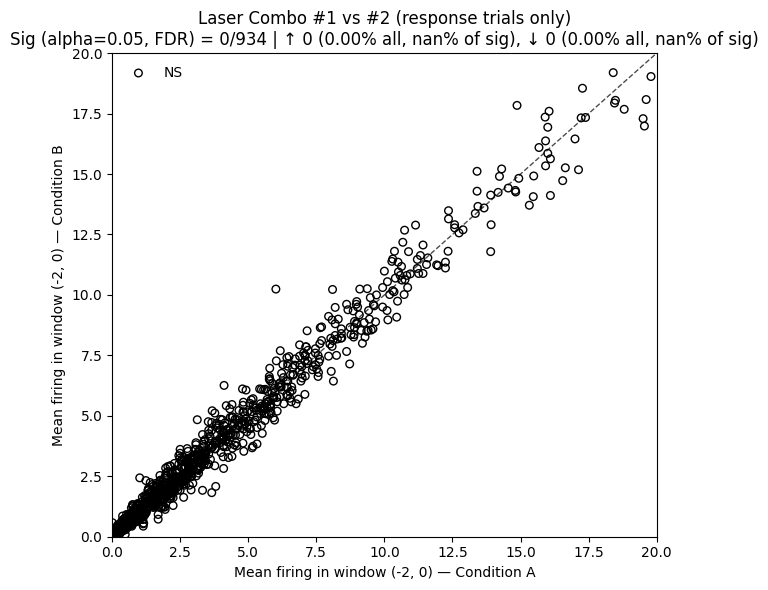

In [16]:
# 1) Load PSTH and NWB
session = 'ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36'
binsize = '0.2'
align = "go_cue"   
target_probes = ["ProbeA", "ProbeC", "ProbeD"]

psth = load_zarr(f"/root/capsule/scratch/psth_results/{session}_{binsize}s.zarr")
nwb_data, tag = NWBUtils.combine_nwb(session_name=session)


### opto trials
import numpy as np
import pandas as pd

# Extract trial-level data
laser_on = np.asarray(nwb_data.trials['laser_on_trial'][:])
laser_start = np.asarray(nwb_data.trials['laser_start'][:])
laser_start_offset = np.asarray(nwb_data.trials['laser_start_offset'][:])
laser_end = np.asarray(nwb_data.trials['laser_end'][:])
laser_end_offset = np.asarray(nwb_data.trials['laser_end_offset'][:])
laser_duration = np.asarray(nwb_data.trials['laser_duration'][:])
trial_ids = np.arange(len(laser_on))

# Build DataFrame (include all trials, but we’ll filter laser_on == 1)
df = pd.DataFrame({
    'trial_id': trial_ids,
    'laser_on_trial': laser_on,
    'laser_start': laser_start,
    'laser_start_offset': laser_start_offset,
    'laser_end': laser_end,
    'laser_end_offset': laser_end_offset,
    'laser_duration': laser_duration,
})

# Keep only trials with laser_on_trial == 1
df_laser = df[df['laser_on_trial'] == 1].copy()

# Group by all laser parameters and aggregate trial IDs
summary = (
    df_laser
    .groupby(['laser_start', 'laser_start_offset', 'laser_end', 'laser_end_offset', 'laser_duration'])
    .agg(
        n_trials=('trial_id', 'size'),
        trial_ids=('trial_id', lambda x: list(x))
    )
    .reset_index()
    .sort_values('n_trials', ascending=False)
)

print(summary)
####


# 2) Build your trial sets (absolute trial IDs)
#    For example: take two laser timing combinations or laser vs. non-laser response trials

#trials_b = np.array(summary['trial_ids'][1], dtype=int)          # ITI
trials_b = np.array(summary['trial_ids'][0], dtype=int)          # go cue


#trials_a = np.array(summary['trial_ids'][1], dtype=int)-1          # ITI
trials_a = np.array(summary['trial_ids'][0], dtype=int)-1          # go cue

# Or intersect with response-only IDs if needed:
# response_ids = np.asarray(df['response_trials'][0], dtype=int)
# trials_a = np.intersect1d(trials_a, response_ids)
# trials_b = np.intersect1d(trials_b, response_ids)

# 3) Choose probes and call the function
out = plot_psth_condition_scatter(
    psth_ds=psth,
    nwb_data=nwb_data,
    trials_a=trials_a,
    trials_b=trials_b,
    target_probes=target_probes,     # your chosen probes
    align=align,
    time_window=(-2, 0),
    alpha=0.05,
    use_fdr=True,
    equal_var=False,                        # Welch's t-test
    title="Laser Combo #1 vs #2 (response trials only)",
    save_path="/root/capsule/scratch/tmp/QLearning_L2F1_softmax-sumQ-1"
)

# Access results if needed:
mean_a = out['mean_a']; mean_b = out['mean_b']
pvals = out['pvals']; sig_mask = out['sig_mask']; unit_ids = out['unit_ids']


In [149]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from typing import Sequence, Optional, Literal
from dataclasses import dataclass

@dataclass
class MultiGroupTimecourseResult:
    time: np.ndarray                      # (T,)
    group_labels: list
    mean_over_units: np.ndarray           # (G, T)
    spread_over_units: np.ndarray         # (G, T)  SEM or 95% CI half-width
    n_units: int
    n_trials_per_group: list
    per_unit_timecourses: np.ndarray      # (G, U, T) per-unit trial-avg timecourses
    unit_ids: np.ndarray                  # (U,)
    align: str
    fig: plt.Figure
    ax: plt.Axes

def plot_multi_group_timecourses(
    psth_ds: xr.Dataset,
    nwb_data,
    trial_groups: Sequence[Sequence[int] | np.ndarray],
    group_labels: Optional[Sequence[str]] = None,
    *,
    target_probes: Sequence[str],
    align: Literal["go_cue", "reward_go_cue_start"] = "go_cue",
    time_window: Optional[tuple[float, float]] = None,      # None = use full time
    statistic_across_trials: Literal["mean", "median"] = "mean",
    ci: Literal["sem", "95"] = "sem",                       # variability across units
    smooth_sigma: Optional[float] = None,                   # Gaussian sigma (samples), None=off
    colors: Optional[Sequence[str]] = None,
    title: Optional[str] = None,
) -> MultiGroupTimecourseResult:
    """
    Plot average firing rate (across all neurons) over time for multiple trial groups.

    Pipeline per group:
      (unit x trial x time) → average across trials per unit → (unit x time)
      then average across units → (time). Error = SEM or 95% CI across units.
    """

    # ----- choose data variable / trial dims from align -----
    if align == "go_cue":
        var = "psth_go_cue"
        trial_dim = "trial_go_cue"
        trial_coord = "trial_index_go_cue"
    elif align == "reward_go_cue_start":
        var = "psth_reward_go_cue_start"
        trial_dim = "trial_reward_go_cue_start"
        trial_coord = "trial_index_reward_go_cue_start"
    else:
        raise ValueError(f"Unknown align='{align}'")

    if var not in psth_ds.data_vars:
        raise KeyError(f"{var} not found in psth dataset data_vars.")
    if "unit_index" not in psth_ds.coords:
        raise KeyError("psth_ds must have a 'unit_index' coordinate (absolute NWB unit IDs).")

    da = psth_ds[var]  # (unit, trial, time)

    # ----- filter UNITS by target_probes -----
    device_names = np.asarray(nwb_data.units['device_name'][:])
    if device_names.dtype.kind in {"S", "O"}:
        device_names = device_names.astype(str)
    keep_rows = np.where(np.isin(device_names, np.asarray(target_probes).astype(str)))[0]
    avail_labels = psth_ds['unit_index'].values.astype(int)   # absolute unit IDs present in dataset
    unit_pos = np.nonzero(np.isin(avail_labels, keep_rows))[0]
    if unit_pos.size == 0:
        raise RuntimeError(f"No units remain after filtering to probes {list(target_probes)}.")
    da = da.isel(unit=unit_pos)
    unit_ids = avail_labels[unit_pos]
    U = da.sizes["unit"]

    # ----- time vector (and optional window slice) -----
    time = psth_ds["time"].values
    if time_window is not None:
        t0, t1 = time_window
        tmask = (time >= t0) & (time <= t1)
        if not np.any(tmask):
            raise ValueError(f"time_window {time_window} selects no samples in 'time'.")
        da = da.sel(time=tmask)
        time = time[tmask]

    T = time.shape[0]

    # Optional smoothing (Gaussian conv along time)
    def _gaussian_smooth(arr_2d: np.ndarray, sigma: float) -> np.ndarray:
        # arr_2d: (n_rows, T)
        if sigma is None or sigma <= 0:
            return arr_2d
        # simple causal-neutral discrete Gaussian via FFT
        import numpy as _np
        # kernel len ~ 6*sigma (odd)
        k = int(6 * sigma) | 1
        x = _np.arange(k) - k // 2
        ker = _np.exp(-0.5 * (x / sigma) ** 2)
        ker = ker / ker.sum()
        # pad reflect, convolve per row
        pad = k // 2
        out = _np.empty_like(arr_2d)
        for i in range(arr_2d.shape[0]):
            row = arr_2d[i]
            padrow = _np.pad(row, pad, mode="reflect")
            out[i] = _np.convolve(padrow, ker, mode="valid")
        return out

    # ----- map absolute trial IDs to positions -----
    if trial_coord not in psth_ds.coords:
        raise KeyError(f"Missing '{trial_coord}' coordinate in dataset.")
    trial_labels = psth_ds[trial_coord].values.astype(int)

    def _map_trials_to_positions(abs_ids: np.ndarray) -> np.ndarray:
        abs_ids = np.asarray(abs_ids, dtype=int).ravel()
        present = np.intersect1d(abs_ids, trial_labels, assume_unique=False)
        if present.size == 0:
            return np.array([], dtype=int)
        pos_by_id = {tid: i for i, tid in enumerate(trial_labels)}
        return np.array([pos_by_id[tid] for tid in present], dtype=int)

    # Normalize inputs
    groups = [np.asarray(g, dtype=int).ravel() for g in trial_groups]
    G = len(groups)
    if group_labels is None:
        group_labels = [f"G{i+1}" for i in range(G)]
    else:
        group_labels = list(group_labels)
        if len(group_labels) != G:
            raise ValueError("Length of group_labels must match number of trial_groups.")
    if colors is not None and len(colors) != G:
        raise ValueError("If provided, 'colors' length must equal number of groups.")

    # ----- per-group per-unit timecourses -----
    # For each group: (unit, trial, time) -> average over trials => (unit, time)
    per_unit_timecourses = np.full((G, U, T), np.nan, dtype=float)
    n_trials_per_group = []
    for g, trials in enumerate(groups):
        idx = _map_trials_to_positions(trials)
        n_trials_per_group.append(int(idx.size))
        if idx.size == 0:
            continue
        vals = da.isel({trial_dim: idx}).values  # (U, Tg, T)
        if statistic_across_trials == "mean":
            per_unit = np.nanmean(vals, axis=1)  # (U, T)
        elif statistic_across_trials == "median":
            per_unit = np.nanmedian(vals, axis=1)  # (U, T)
        else:
            raise ValueError("statistic_across_trials must be 'mean' or 'median'")

        # optional smoothing per unit along time
        if smooth_sigma is not None and smooth_sigma > 0:
            per_unit = _gaussian_smooth(per_unit, smooth_sigma)

        per_unit_timecourses[g] = per_unit

    # Valid units: at least one finite in any group/time
    valid_units = np.any(np.isfinite(per_unit_timecourses.reshape(G, U, -1)), axis=(0, 2))
    if not np.any(valid_units):
        raise RuntimeError("No valid units after computing per-unit timecourses (all NaN).")
    U_eff = int(valid_units.sum())

    X = per_unit_timecourses[:, valid_units, :]  # (G, U_eff, T)

    # ----- aggregate across units for each group/time -----
    if ci == "sem":
        mean_over_units = np.nanmean(X, axis=1)  # (G, T)
        denom = np.sqrt(np.sum(np.isfinite(X), axis=1))  # (G, T)
        spread = np.nanstd(X, axis=1, ddof=1) / np.maximum(denom, 1.0)
    elif ci == "95":
        mean_over_units = np.nanmean(X, axis=1)
        denom = np.sqrt(np.sum(np.isfinite(X), axis=1))
        sem = np.nanstd(X, axis=1, ddof=1) / np.maximum(denom, 1.0)
        spread = 1.96 * sem
    else:
        raise ValueError("ci must be 'sem' or '95'")

    # ----- plotting -----
    fig, ax = plt.subplots(figsize=(7.8, 4.8))
    cols = colors if colors is not None else [None] * G
    for g in range(G):
        c = cols[g]
        ax.plot(time, mean_over_units[g], label=group_labels[g], color=c, linewidth=2.0)
        ax.fill_between(
            time,
            mean_over_units[g] - spread[g],
            mean_over_units[g] + spread[g],
            alpha=0.25,
            edgecolor='none',
            facecolor=c
        )

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Average firing rate across units (spikes/s)")
    ttl = title or f"Average firing over time across units — {align}"
    ax.set_title(ttl)
    ax.legend(frameon=False, ncols=min(G, 3))
    ax.grid(alpha=0.3, linestyle="--", linewidth=0.8)
    fig.tight_layout()

    return MultiGroupTimecourseResult(
        time=time,
        group_labels=group_labels,
        mean_over_units=mean_over_units,
        spread_over_units=spread,
        n_units=U_eff,
        n_trials_per_group=n_trials_per_group,
        per_unit_timecourses=X,                     # (G, U_eff, T)
        unit_ids=unit_ids[valid_units],
        align=align,
        fig=fig,
        ax=ax,
    )


Found ephys NWB: /root/capsule/data/ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36/nwb/ecephys_795393_2025-09-15_13-05-25_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36/nwb/ecephys_795393_2025-09-15_13-05-25_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/optogenetics_nwb/795393_2025-09-15_13-05-25.nwb
Successfully read behavior NWB from: /root/capsule/data/optogenetics_nwb/795393_2025-09-15_13-05-25.nwb
Successfully appended units table to behavior NWB.
   laser_start  laser_start_offset laser_end  laser_end_offset  \
1  Trial start                 0.0    Go cue               0.0   
0       Go cue                 0.3        NA               0.0   

   laser_duration  n_trials                                          trial_ids  
1            50.0        40  [8, 18, 39, 66, 81, 107, 121, 153, 166, 184, 2...  
0             3.0        31  [1, 26, 44, 52, 59, 86,

(0.0, 10.0)

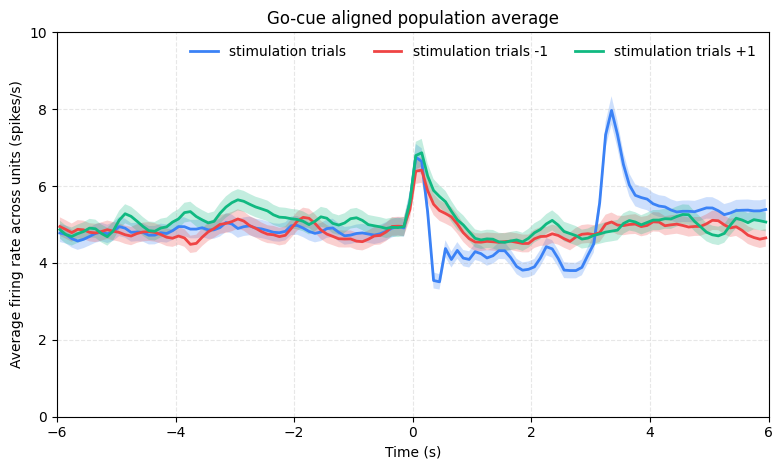

In [156]:
# 1) Load PSTH and NWB
session = 'ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36'
binsize = '0.1'
align = "go_cue"   
target_probes = ["ProbeA", "ProbeC", "ProbeD"]

psth = load_zarr(f"/root/capsule/scratch/{session}_{binsize}s.zarr")
nwb_data, tag = NWBUtils.combine_nwb(session_name=session)


### opto trials
import numpy as np
import pandas as pd

# Extract trial-level data
laser_on = np.asarray(nwb_data.trials['laser_on_trial'][:])
laser_start = np.asarray(nwb_data.trials['laser_start'][:])
laser_start_offset = np.asarray(nwb_data.trials['laser_start_offset'][:])
laser_end = np.asarray(nwb_data.trials['laser_end'][:])
laser_end_offset = np.asarray(nwb_data.trials['laser_end_offset'][:])
laser_duration = np.asarray(nwb_data.trials['laser_duration'][:])
trial_ids = np.arange(len(laser_on))

# Build DataFrame (include all trials, but we’ll filter laser_on == 1)
df = pd.DataFrame({
    'trial_id': trial_ids,
    'laser_on_trial': laser_on,
    'laser_start': laser_start,
    'laser_start_offset': laser_start_offset,
    'laser_end': laser_end,
    'laser_end_offset': laser_end_offset,
    'laser_duration': laser_duration,
})

# Keep only trials with laser_on_trial == 1
df_laser = df[df['laser_on_trial'] == 1].copy()

# Group by all laser parameters and aggregate trial IDs
summary = (
    df_laser
    .groupby(['laser_start', 'laser_start_offset', 'laser_end', 'laser_end_offset', 'laser_duration'])
    .agg(
        n_trials=('trial_id', 'size'),
        trial_ids=('trial_id', lambda x: list(x))
    )
    .reset_index()
    .sort_values('n_trials', ascending=False)
)

print(summary)
####


# 2) Build your trial sets (absolute trial IDs)
#    For example: take two laser timing combinations or laser vs. non-laser response trials

#trials_a = np.array(summary['trial_ids'][1], dtype=int)          # ITI
trials_a = np.array(summary['trial_ids'][0], dtype=int)          # go cue


trials_b =trials_a-1       
trials_c =trials_a+1 



res_tc = plot_multi_group_timecourses(
    psth, nwb_data,
    trial_groups=[trials_a, trials_b, trials_c],
    group_labels=["stimulation trials", "stimulation trials -1", "stimulation trials +1"],
    target_probes=["ProbeA", "ProbeC", "ProbeD"],
    align="go_cue",
    time_window=None,          # full time span
    statistic_across_trials="mean",
    ci="sem",
    smooth_sigma=0.8,         # e.g., 2–4 samples for light smoothing
    colors=["#3b82f6", "#ef4444", "#10b981"],
    title="Go-cue aligned population average"
)
res_tc.ax.set_xlim(-6, 6)
res_tc.ax.set_ylim(0, 10)